# Detection DF same-image experiment


Ce notebook reprend le pipeline habituel, mais avec une configuration volontairement
particuliere :

- le keyframe et la current image sont exactement la meme image
- la profondeur du keyframe est inferree comme d'habitude avec Depth Anything
- les intrinseques restent fixes manuellement

Le but n'est pas de faire un sanity check strict, mais d'observer ce que produit
le notebook habituel quand `source == target`.


### Import


In [1]:
from pathlib import Path
import hashlib
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import cv2
import matplotlib
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import display

if not hasattr(matplotlib, "get_data_path"):
    raise RuntimeError(
        "Matplotlib semble mal installe ou masque par un autre module. "
        f"Module charge : {getattr(matplotlib, '__file__', 'inconnu')}"
    )

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from torchvision.transforms import Compose
except ModuleNotFoundError:
    class Compose:
        def __init__(self, transforms):
            self.transforms = transforms

        def __call__(self, sample):
            for transform in self.transforms:
                sample = transform(sample)
            return sample

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise

import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"
if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything


c:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


### User inputs


In [4]:
IMAGE_PATH = PROJECT_ROOT / "dataset" / "deform_house" / "frame_00000.png"
KEYFRAME_PATH = IMAGE_PATH
TARGET_PATH = IMAGE_PATH

K_user = np.array(
    [
        [459.98449707, 0.0, 360.0],
        [0.0, 456.11392212, 240.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

USER_WIDTH = 720
USER_HEIGHT = 480
USER_FX = float(K_user[0, 0])
USER_FY = float(K_user[1, 1])
USER_CX = float(K_user[0, 2])
USER_CY = float(K_user[1, 2])

print("KEYFRAME_PATH =", KEYFRAME_PATH)
print("TARGET_PATH   =", TARGET_PATH)
print()
print("K_user =")
print(K_user)


KEYFRAME_PATH = c:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\deform_house\frame_00000.png
TARGET_PATH   = c:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\deform_house\frame_00000.png

K_user =
[[459.984497   0.       360.      ]
 [  0.       456.113922 240.      ]
 [  0.         0.         1.      ]]


### Notebook utility functions


In [5]:
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path


def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


class Resize:
    def __init__(
        self,
        width,
        height,
        resize_target=True,
        keep_aspect_ratio=False,
        ensure_multiple_of=1,
        resize_method="lower_bound",
        image_interpolation_method=cv2.INTER_AREA,
    ):
        self._width = width
        self._height = height
        self._resize_target = resize_target
        self._keep_aspect_ratio = keep_aspect_ratio
        self._multiple_of = ensure_multiple_of
        self._resize_method = resize_method
        self._image_interpolation_method = image_interpolation_method

    def constrain_to_multiple_of(self, x, min_val=0, max_val=None):
        y = (np.round(x / self._multiple_of) * self._multiple_of).astype(int)

        if max_val is not None and y > max_val:
            y = (np.floor(x / self._multiple_of) * self._multiple_of).astype(int)

        if y < min_val:
            y = (np.ceil(x / self._multiple_of) * self._multiple_of).astype(int)

        return y

    def get_size(self, width, height):
        scale_height = self._height / height
        scale_width = self._width / width

        if self._keep_aspect_ratio:
            if self._resize_method == "lower_bound":
                if scale_width > scale_height:
                    scale_height = scale_width
                else:
                    scale_width = scale_height
            elif self._resize_method == "upper_bound":
                if scale_width < scale_height:
                    scale_height = scale_width
                else:
                    scale_width = scale_height
            elif self._resize_method == "minimal":
                if abs(1 - scale_width) < abs(1 - scale_height):
                    scale_height = scale_width
                else:
                    scale_width = scale_height
            else:
                raise ValueError(f"resize_method {self._resize_method} not implemented")

        if self._resize_method == "lower_bound":
            new_height = self.constrain_to_multiple_of(scale_height * height, min_val=self._height)
            new_width = self.constrain_to_multiple_of(scale_width * width, min_val=self._width)
        elif self._resize_method == "upper_bound":
            new_height = self.constrain_to_multiple_of(scale_height * height, max_val=self._height)
            new_width = self.constrain_to_multiple_of(scale_width * width, max_val=self._width)
        elif self._resize_method == "minimal":
            new_height = self.constrain_to_multiple_of(scale_height * height)
            new_width = self.constrain_to_multiple_of(scale_width * width)
        else:
            raise ValueError(f"resize_method {self._resize_method} not implemented")

        return (new_width, new_height)

    def __call__(self, sample):
        width, height = self.get_size(sample["image"].shape[1], sample["image"].shape[0])
        sample["image"] = cv2.resize(
            sample["image"],
            (width, height),
            interpolation=self._image_interpolation_method,
        )
        return sample


class NormalizeImage:
    def __init__(self, mean, std):
        self._mean = mean
        self._std = std

    def __call__(self, sample):
        sample["image"] = (sample["image"] - self._mean) / self._std
        return sample


class PrepareForNet:
    def __call__(self, sample):
        image = np.transpose(sample["image"], (2, 0, 1))
        sample["image"] = np.ascontiguousarray(image).astype(np.float32)
        return sample


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


def display_figure(fig):
    display(fig)
    plt.close(fig)


### Extract keyframe


In [6]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_depth_mask = depth_to_invdepth(keyframe_depth)


In [7]:
print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_depth_mask.mean()))


keyframe_image_path = c:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\deform_house\frame_00000.png
keyframe_image shape = (480, 720) dtype = uint8
keyframe_depth shape = (480, 720) dtype = float32
depth min/max = 0.0 51.03537368774414
valid depth ratio = 0.9080642361111111


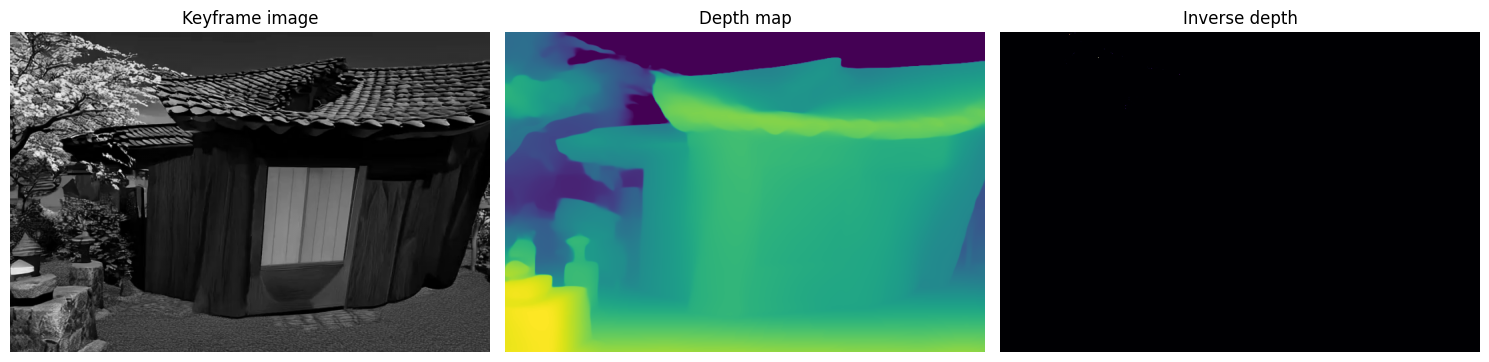

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")
axes[0].axis("off")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")
axes[1].axis("off")

axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")
axes[2].axis("off")

fig.tight_layout()
display_figure(fig)


### Camera used by the pipeline


In [9]:
loaded_height, loaded_width = keyframe_image.shape[:2]

intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array(
    [
        [cam.fx[0], 0.0, cam.cx[0]],
        [0.0, cam.fy[0], cam.cy[0]],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("Intrinsics defined at notebook level:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 720
  height = 480

Intrinsics defined at notebook level:
{'width': 720, 'height': 480, 'fx': 459.98449707, 'fy': 456.11392212, 'cx': 360.0, 'cy': 240.0}

K_user =
[[459.984497   0.       360.      ]
 [  0.       456.113922 240.      ]
 [  0.         0.         1.      ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[408.875109   0.       320.      ]
 [  0.       456.113922 240.      ]
 [  0.         0.         1.      ]]


In [10]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.8888888888888888
  scale_y = 1.0

  USER_FX -> cam.fx[0] : 459.98449707 -> 408.8751085066666
  USER_FY -> cam.fy[0] : 456.11392212 -> 456.11392212
  USER_CX -> cam.cx[0] : 360.0 -> 320.0
  USER_CY -> cam.cy[0] : 240.0 -> 240.0

Expected level-0 values after internal resize:
  expected fx = 408.8751085066666
  expected fy = 456.11392212
  expected cx = 320.0
  expected cy = 240.0


### Verification for every pyramid level


In [11]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 408.875109, 456.113922
  cx, cy = 320.000000, 240.000000
  K =
[[408.875109   0.       320.      ]
 [  0.       456.113922 240.      ]
 [  0.         0.         1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 204.437554, 228.056961
  cx, cy = 160.000000, 120.000000
  K =
[[204.437554   0.       160.      ]
 [  0.       228.056961 120.      ]
 [  0.         0.         1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 102.218777, 114.028481
  cx, cy = 80.000000, 60.000000
  K =
[[102.218777   0.        80.      ]
 [  0.       114.028481  60.      ]
 [  0.         0.         1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 51.109389, 57.014240
  cx, cy = 40.000000, 30.000000
  K =
[[51.109389  0.       40.      ]
 [ 0.       57.01424  30.      ]
 [ 0.        0.        1.      ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 

In [12]:
keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


### Extract the current image

Ici la current image est volontairement la meme que le keyframe.


In [13]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)


### Recap


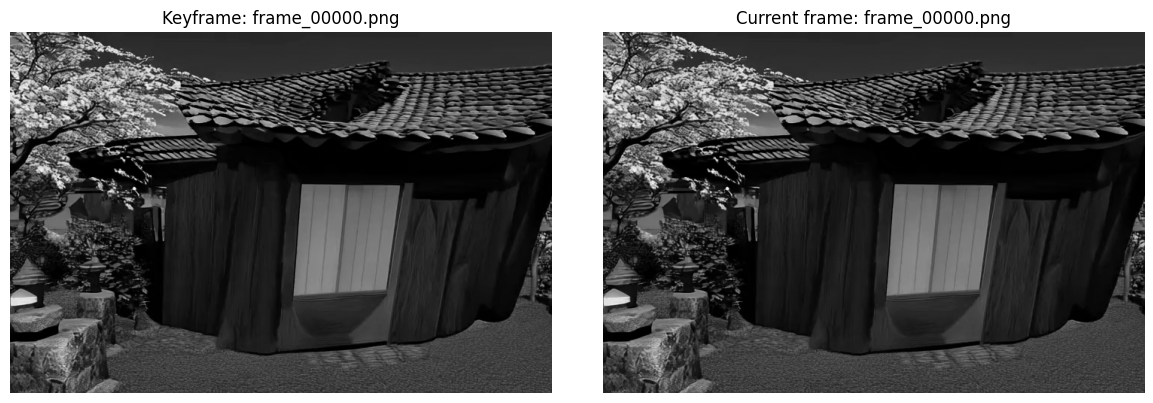

same pixel array -> True


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")
axes[0].axis("off")

axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")
axes[1].axis("off")

fig.tight_layout()
display_figure(fig)

print("same pixel array ->", bool(np.array_equal(keyframe_image, current_image)))


### Initial pose and optimization updates


In [15]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)
initial_error_lvl1, _ = pose_solver.computeError(current_frame, keyframe, lvl=1)
initial_error_lvl0, _ = pose_solver.computeError(current_frame, keyframe, lvl=0)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)
print("  level 1 =", initial_error_lvl1)
print("  level 0 =", initial_error_lvl0)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 408.8751085066666
  pose_solver.camera.fy[0] = 456.11392212
  pose_solver.camera.cx[0] = 320.0
  pose_solver.camera.cy[0] = 240.0

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 408.8751085066666, 'fy': 456.11392212, 'cx': 320.0, 'cy': 240.0}

Initial photometric errors before optimization:
  level 4 = 3.9160833829195825e-27
  level 3 = 1.7460712760754393e-26
  level 2 = 6.275134780554702e-26
  level 1 = 1.448591885817253e-25
  level 0 = 3.051293568934502e-25


`optPose(...)` effectue les memes etapes que dans le notebook habituel :

- calcul d'une erreur
- linearisation locale
- calcul d'un increment de pose
- acceptation ou rejet selon l'amelioration obtenue


In [16]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)
final_error_lvl1, _ = pose_solver.computeError(current_frame, keyframe, lvl=1)
final_error_lvl0, _ = pose_solver.computeError(current_frame, keyframe, lvl=0)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)
print("  level 1 =", final_error_lvl1)
print("  level 0 =", final_error_lvl0)


lvl:  4  initial error:  3.9160833829195825e-27
update too small, level converged! it:  1  error:  3.9160833829195825e-27  lambda:  0.2
lvl:  3  initial error:  1.7460712760754393e-26
update too small, level converged! it:  1  error:  1.7460712760754393e-26  lambda:  0.2
lvl:  2  initial error:  6.275134780554702e-26
update too small, level converged! it:  1  error:  6.275134780554702e-26  lambda:  0.2
Final photometric errors after optimization:
  level 4 = 3.9160833829195825e-27
  level 3 = 1.7460712760754393e-26
  level 2 = 6.275134780554702e-26
  level 1 = 1.448591885817253e-25
  level 0 = 3.051293568934502e-25


In [17]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
    "lvl1_initial": float(initial_error_lvl1),
    "lvl1_final": float(final_error_lvl1),
    "lvl0_initial": float(initial_error_lvl0),
    "lvl0_final": float(final_error_lvl0),
}

print("Optimization summary:")
for lvl in [4, 3, 2, 1, 0]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = initial_value - final_value
    print(f"  level {lvl}: initial={initial_value:.12e}, final={final_value:.12e}, improvement={improvement:.12e}")


Optimization summary:
  level 4: initial=3.916083382920e-27, final=3.916083382920e-27, improvement=0.000000000000e+00
  level 3: initial=1.746071276075e-26, final=1.746071276075e-26, improvement=0.000000000000e+00
  level 2: initial=6.275134780555e-26, final=6.275134780555e-26, improvement=0.000000000000e+00
  level 1: initial=1.448591885817e-25, final=1.448591885817e-25, improvement=0.000000000000e+00
  level 0: initial=3.051293568935e-25, final=3.051293568935e-25, improvement=0.000000000000e+00


### Output matrix: the final extrinsic matrix


In [18]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00000.png relative to frame_00000.png:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


---
### x'=HX (core of the notebook)

On garde maintenant la meme logique que dans le notebook habituel :

- on reprojette chaque pixel valide du keyframe dans l'image courante
- on compare l'intensite du keyframe a l'intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides


In [19]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)
    reprojected_image = np.full((height, width), np.nan, dtype=np.float32)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            reprojected_image[y, x] = observed_intensity
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "reprojected_image": reprojected_image,
        "level": lvl,
    }


### Evaluation


In [20]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)


In [21]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 8.457819658247846e-20


In [22]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]
total_valid_pixels = int(valid_abs_errors.size)
mean_abs_error = float(valid_abs_errors.mean()) if total_valid_pixels > 0 else None
max_abs_error = float(valid_abs_errors.max()) if total_valid_pixels > 0 else None

num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  mean abs difference      =", mean_abs_error)
print("  max abs difference       =", max_abs_error)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 277188
  mean abs difference      = 1.8598158766074818e-13
  max abs difference       = 1.1482370609883219e-11
  difference > 200         = 0
  150 <= difference <= 200 = 0
  100 <= difference < 150  = 0
   50 <= difference < 100  = 0
   30 <= difference < 50   = 0
   10 <= difference < 30   = 0
    0 <= difference < 10   = 277188


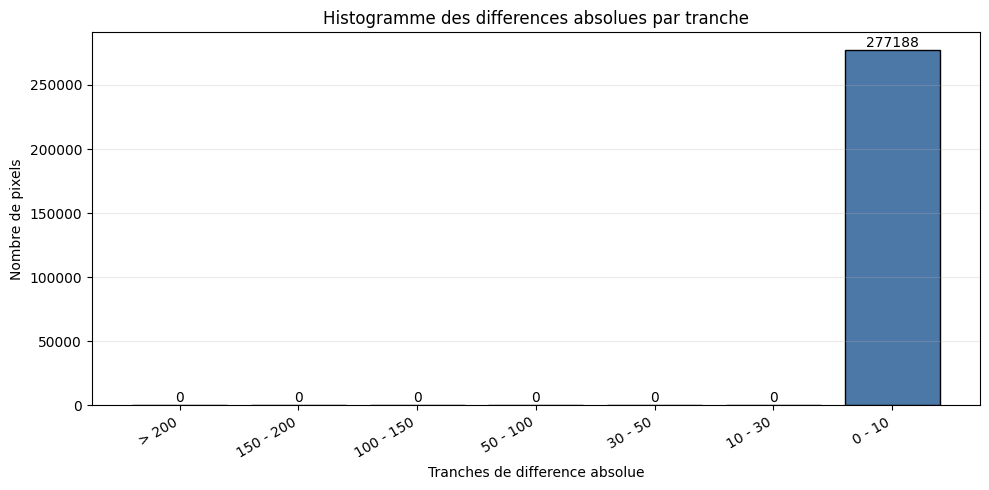

In [23]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

fig = plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des differences absolues par tranche")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
display_figure(fig)


### Squared photometric error map


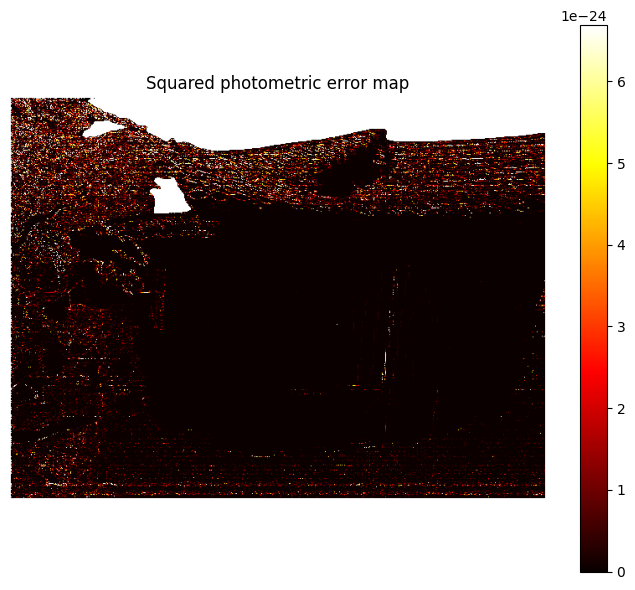

In [24]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

fig = plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.tight_layout()
display_figure(fig)


### Reprojected image and absolute difference


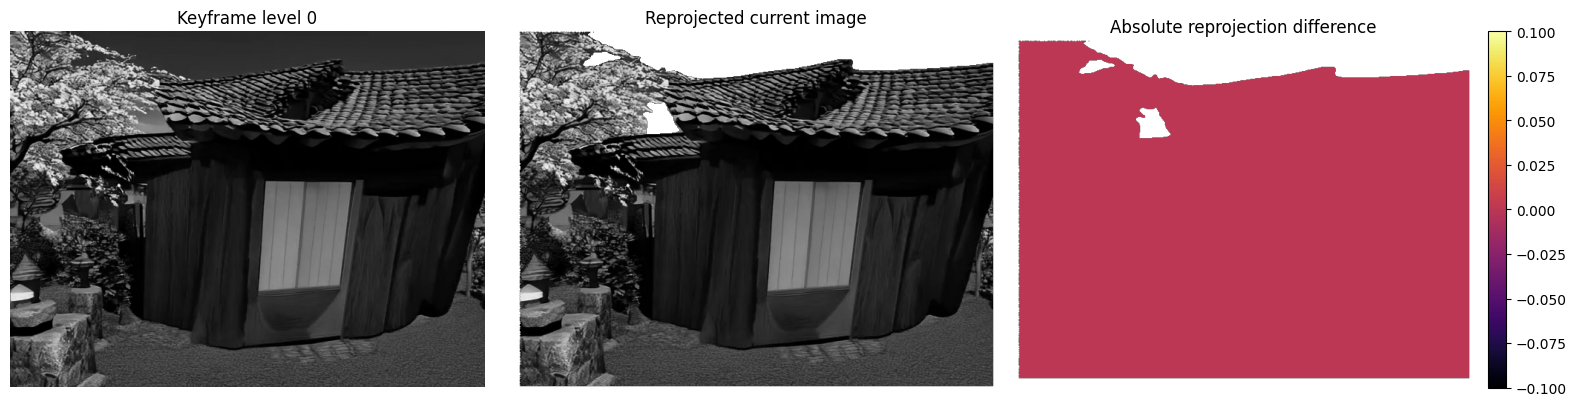

In [25]:
reprojected_image = evaluation["reprojected_image"]

abs_difference = np.full_like(reprojected_image, np.nan, dtype=np.float32)
abs_difference[valid_mask] = np.abs(
    keyframe.image[0][valid_mask].astype(np.float32) - reprojected_image[valid_mask]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(keyframe.image[0], cmap="gray")
axes[0].set_title("Keyframe level 0")
axes[0].axis("off")

axes[1].imshow(reprojected_image, cmap="gray")
axes[1].set_title("Reprojected current image")
axes[1].axis("off")

vmax_abs = float(np.nanpercentile(abs_difference[valid_mask], 99)) if np.any(valid_mask) else 1.0
im = axes[2].imshow(abs_difference, cmap="inferno", vmin=0, vmax=vmax_abs)
axes[2].set_title("Absolute reprojection difference")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
display_figure(fig)


In [26]:
print("Only evaluation metric kept here:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")
print()
print("This notebook is meant to observe the behaviour of the usual pipeline when source == target.")


Only evaluation metric kept here:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels

This notebook is meant to observe the behaviour of the usual pipeline when source == target.
